In [2]:
# Retail & Marketing Analytics Project
# Part 3: Exploratory Data Analysis (EDA)

"""
Project: Retail & Marketing Analytics - Customer Segmentation & Sales Optimization
Part: 03 - Exploratory Data Analysis (EDA)
Date: 06-16-2026

Objective:
- Univariate analysis
- Bivariate analysis
- Multivariate analysis
- Time series analysis
- Customer behavior analysis
- Product performance analysis
- Generate insights
"""

# ============================================================================
# 1. IMPORT LIBRARIES AND LOAD CLEANED DATA
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import os
import warnings

warnings.filterwarnings('ignore')

# Set visual style for publication-grade charts
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# Create directories for saving figures if they don't exist
os.makedirs('outputs/figures/eda', exist_ok=True)

# Load your cleaned data
df = pd.read_csv('data/processed/cleaned_retail_sales.csv')

# Parse your custom Period column back to timestamp format for plotting libraries
if 'MONTH-PERIOD' in df.columns:
    df['MONTH-PERIOD'] = pd.to_datetime(df['MONTH-PERIOD'])

print("="*80)
print("EXPLORATORY DATA ANALYSIS (EDA)")
print("="*80)
print(f"Dataset Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
if 'MONTH-PERIOD' in df.columns:
    print(f"Analysis Period: {df['MONTH-PERIOD'].min().strftime('%B %Y')} to {df['MONTH-PERIOD'].max().strftime('%B %Y')}")

EXPLORATORY DATA ANALYSIS (EDA)
Dataset Shape: 29,996 rows x 27 columns
Analysis Period: January 2020 to September 2020



UNIVARIATE ANALYSIS - NUMERICAL VARIABLES
✓ Saved: 05_numerical_distributions.png


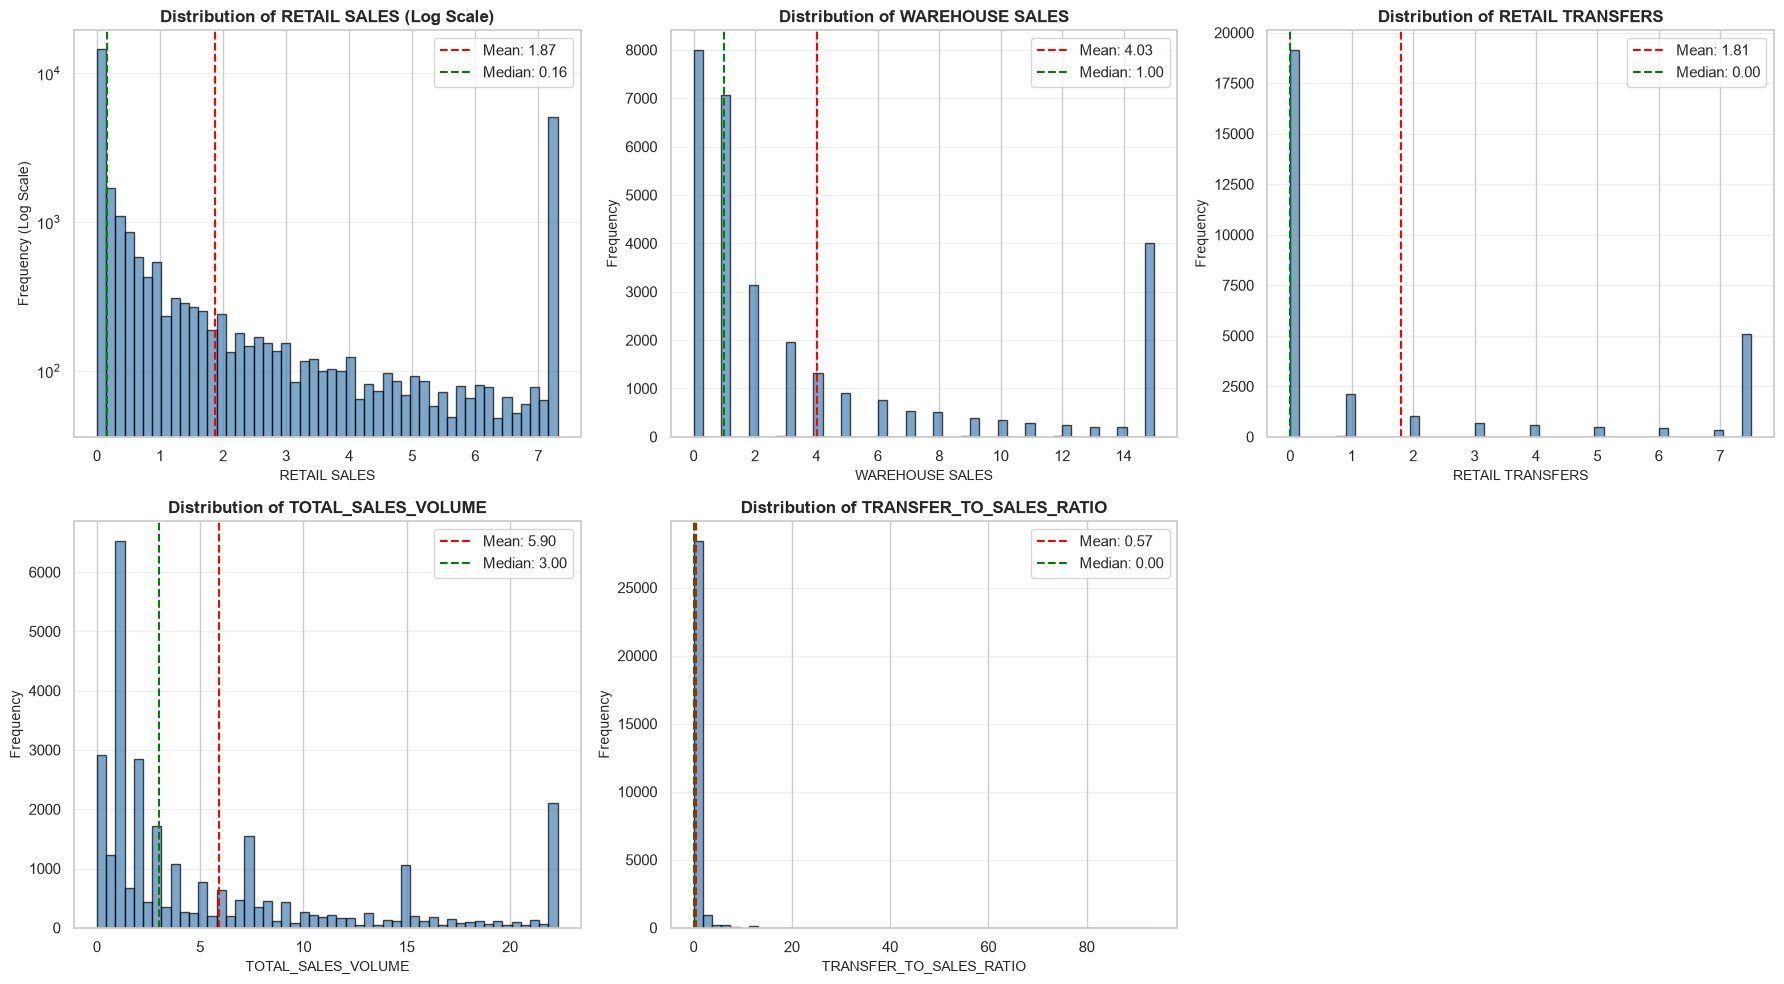


 Statistical Summary:
       RETAIL SALES  WAREHOUSE SALES  RETAIL TRANSFERS  TOTAL_SALES_VOLUME  \
count      29996.00         29996.00          29996.00            29996.00   
mean           1.87             4.03              1.81                5.90   
std            2.81             5.16              2.91                6.67   
min            0.00             0.00              0.00                0.00   
25%            0.00             0.00              0.00                1.00   
50%            0.16             1.00              0.00                3.00   
75%            2.92             6.00              3.00                8.22   
max            7.31            15.00              7.50               22.31   

       TRANSFER_TO_SALES_RATIO  
count                 29996.00  
mean                      0.57  
std                       1.77  
min                       0.00  
25%                       0.00  
50%                       0.00  
75%                       1.03  
max       

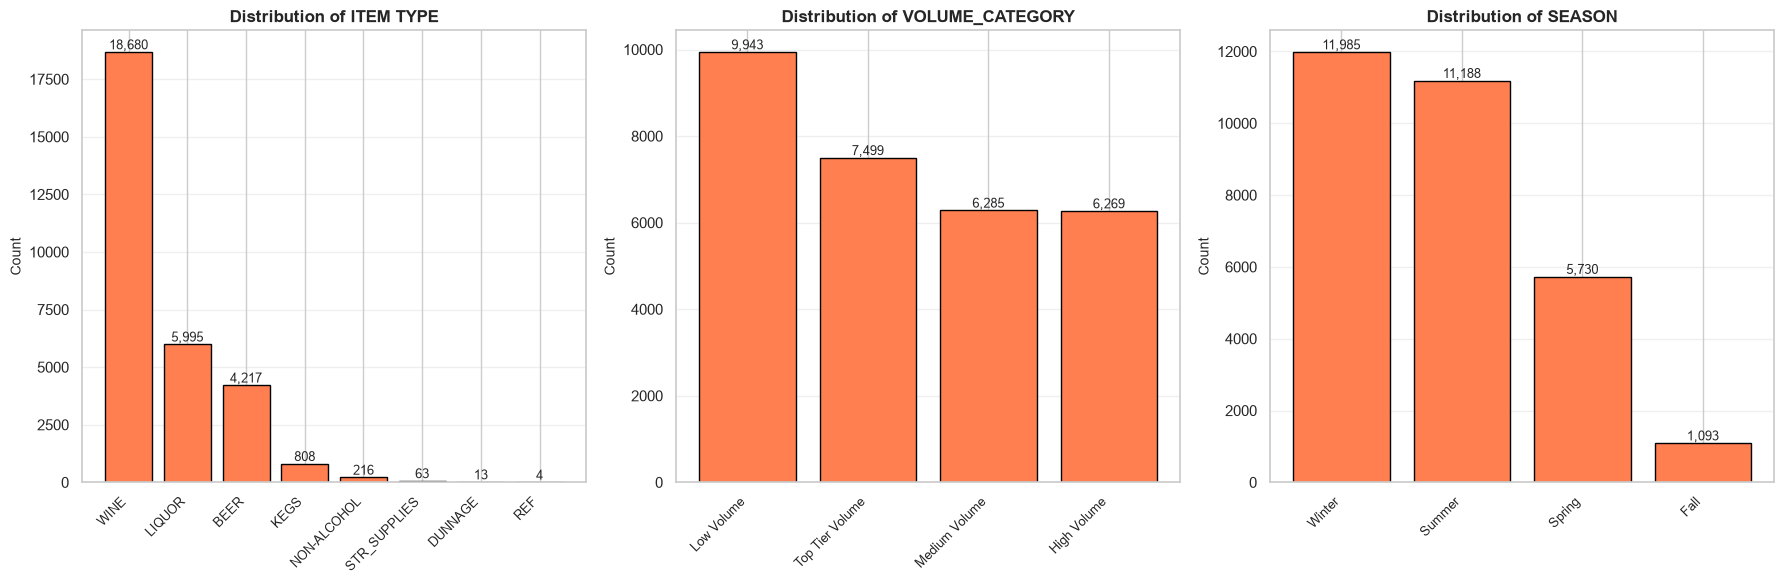


 Categorical Variable Counts:

ITEM TYPE (Showing Top 10):
ITEM TYPE
WINE            18680
LIQUOR           5995
BEER             4217
KEGS              808
NON-ALCOHOL       216
STR_SUPPLIES       63
DUNNAGE            13
REF                 4
Name: count, dtype: int64

VOLUME_CATEGORY (Showing Top 10):
VOLUME_CATEGORY
Low Volume         9943
Top Tier Volume    7499
Medium Volume      6285
High Volume        6269
Name: count, dtype: int64

SEASON (Showing Top 10):
SEASON
Winter    11985
Summer    11188
Spring     5730
Fall       1093
Name: count, dtype: int64


In [3]:
# ============================================================================
# 2. UNIVARIATE ANALYSIS - NUMERICAL VARIABLES
# ============================================================================

print("\n" + "="*80)
print("UNIVARIATE ANALYSIS - NUMERICAL VARIABLES")
print("="*80)

# Select your actual numerical columns (Original numericals + newly engineered features)
numerical_cols = ['RETAIL SALES', 'WAREHOUSE SALES', 'RETAIL TRANSFERS', 
                  'TOTAL_SALES_VOLUME', 'TRANSFER_TO_SALES_RATIO']
numerical_cols = [col for col in numerical_cols if col in df.columns]

# Create a clean subplot grid (Adjusted dimensions to 2x3 for up to 5 metrics)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, col in enumerate(numerical_cols):
    if idx < len(axes):
        # Drop missing values for clean rendering
        clean_series = df[col].dropna()
        
        # Histogram with explicit step styling
        axes[idx].hist(clean_series, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
        axes[idx].set_title(f'Distribution of {col}', fontweight='bold', fontsize=12)
        axes[idx].set_xlabel(col, fontsize=10)
        axes[idx].set_ylabel('Frequency', fontsize=10)
        
        # Add Mean and Median tracking lines
        col_mean = clean_series.mean()
        col_median = clean_series.median()
        axes[idx].axvline(col_mean, color='red', linestyle='--', 
                          label=f'Mean: {col_mean:.2f}')
        axes[idx].axvline(col_median, color='green', linestyle='--', 
                          label=f'Median: {col_median:.2f}')
        
        # Log scale flag for high skew distribution visualizations
        if col_median > 0 and (col_mean / col_median) > 5:
            axes[idx].set_yscale('log')
            axes[idx].set_ylabel('Frequency (Log Scale)', fontsize=10)
            axes[idx].set_title(f'Distribution of {col} (Log Scale)', fontweight='bold', fontsize=12)

        axes[idx].legend()
        axes[idx].grid(axis='y', alpha=0.3)

# Remove empty subplots
for idx in range(len(numerical_cols), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.savefig('outputs/figures/05_numerical_distributions.png', dpi=300, bbox_inches='tight')
print("✓ Saved: 05_numerical_distributions.png")
plt.show()

# Statistical summary
print("\n Statistical Summary:")
print(df[numerical_cols].describe().round(2))

# Skewness and Kurtosis
print("\n Skewness and Kurtosis:")
for col in numerical_cols:
    skew = df[col].skew()
    kurt = df[col].kurtosis()
    print(f"{col:25s} - Skewness: {skew:6.2f}, Kurtosis: {kurt:6.2f}")


# ============================================================================
# 3. UNIVARIATE ANALYSIS - CATEGORICAL VARIABLES
# ============================================================================

print("\n" + "="*80)
print("UNIVARIATE ANALYSIS - CATEGORICAL VARIABLES")
print("="*80)

# Select your specific categorical tracking groups
categorical_cols = ['ITEM TYPE', 'VOLUME_CATEGORY', 'SEASON']
categorical_cols = [col for col in categorical_cols if col in df.columns]

# Create bar plots matching your original format
fig, axes = plt.subplots(1, 3, figsize=(18, 6)) # Single row configuration for the 3 categories
axes = axes.flatten()

for idx, col in enumerate(categorical_cols):
    if idx < len(axes):
        # Grab the value counts (top 8 max to keep visual clutter at zero)
        value_counts = df[col].value_counts().head(8)
        
        axes[idx].bar(range(len(value_counts)), value_counts.values, color='coral', edgecolor='black')
        axes[idx].set_xticks(range(len(value_counts)))
        
        # Format the label strings for text alignment
        labels = [str(x)[:15] + '...' if len(str(x)) > 15 else str(x) for x in value_counts.index]
        axes[idx].set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
        
        axes[idx].set_title(f'Distribution of {col}', fontweight='bold', fontsize=12)
        axes[idx].set_ylabel('Count', fontsize=10)
        axes[idx].grid(axis='y', alpha=0.3)
        
        # Add value labels directly on top of bars
        for i, v in enumerate(value_counts.values):
            axes[idx].text(i, v, f"{v:,}", ha='center', va='bottom', fontsize=9)

# Remove empty subplots if configuration leaves a gap
for idx in range(len(categorical_cols), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.savefig('outputs/figures/06_categorical_distributions.png', dpi=300, bbox_inches='tight')
print("✓ Saved: 06_categorical_distributions.png")
plt.show()

# Print value counts
print("\n Categorical Variable Counts:")
for col in categorical_cols:
    print(f"\n{col} (Showing Top 10):")
    print(df[col].value_counts().head(10))


BIVARIATE ANALYSIS

 Total Combined Volume by Item Type:
              Total_Volume  Avg_Volume  Record_Count
ITEM TYPE                                           
WINE              97761.50        5.23         18680
BEER              47042.84       11.16          4217
LIQUOR            26504.63        4.42          5995
KEGS               3868.00        4.79           808
NON-ALCOHOL        1706.09        7.90           216
STR_SUPPLIES        174.68        2.77            63
REF                  21.92        5.48             4
DUNNAGE               0.00        0.00            13
✓ Saved: 07_volume_by_category.html

 Evaluating Channel Dominance per Item Type:
              RETAIL SALES  WAREHOUSE SALES
ITEM TYPE                                  
BEER               9218.67         37824.17
DUNNAGE               0.00             0.00
KEGS                  0.00          3868.00
LIQUOR            21309.35          5195.28
NON-ALCOHOL         923.09           783.00
REF                  2

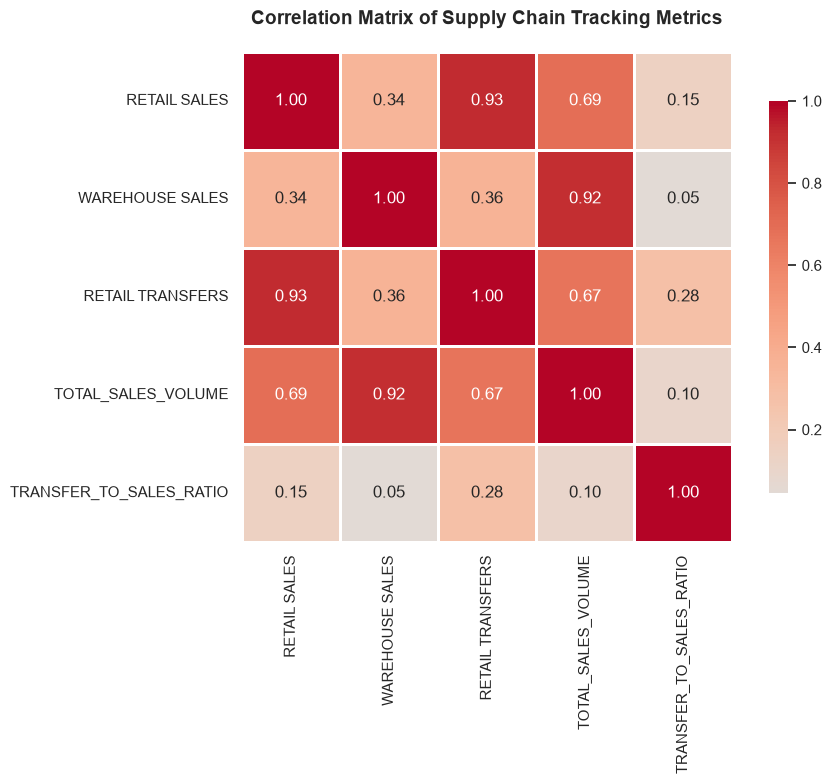


Correlation Coefficients:
                         RETAIL SALES  WAREHOUSE SALES  RETAIL TRANSFERS  \
RETAIL SALES                 1.000000         0.343767          0.926195   
WAREHOUSE SALES              0.343767         1.000000          0.363366   
RETAIL TRANSFERS             0.926195         0.363366          1.000000   
TOTAL_SALES_VOLUME           0.686939         0.918573          0.671042   
TRANSFER_TO_SALES_RATIO      0.147514         0.045161          0.282077   

                         TOTAL_SALES_VOLUME  TRANSFER_TO_SALES_RATIO  
RETAIL SALES                       0.686939                 0.147514  
WAREHOUSE SALES                    0.918573                 0.045161  
RETAIL TRANSFERS                   0.671042                 0.282077  
TOTAL_SALES_VOLUME                 1.000000                 0.097039  
TRANSFER_TO_SALES_RATIO            0.097039                 1.000000  


In [4]:
# ============================================================================
# 4. BIVARIATE ANALYSIS
# ============================================================================

print("\n" + "="*80)
print("BIVARIATE ANALYSIS")
print("="*80)

# 4.1 Volume Distribution by Item Type (Replacing Product_Category)
if 'ITEM TYPE' in df.columns and 'TOTAL_SALES_VOLUME' in df.columns:
    print("\n Total Combined Volume by Item Type:")
    category_volume = df.groupby('ITEM TYPE')['TOTAL_SALES_VOLUME'].agg(['sum', 'mean', 'count']).round(2)
    category_volume.columns = ['Total_Volume', 'Avg_Volume', 'Record_Count']
    category_volume = category_volume.sort_values('Total_Volume', ascending=False)
    print(category_volume)
    
    # Interactive Bar Chart
    fig = px.bar(category_volume.reset_index(), 
                 x='ITEM TYPE', 
                 y='Total_Volume',
                 title='Total Combined Supply Volume by Item Type',
                 labels={'Total_Volume': 'Total Units Transacted', 'ITEM TYPE': 'Item Category'},
                 color='Total_Volume',
                 color_continuous_scale='viridis')
    fig.update_layout(xaxis_tickangle=-45)
    fig.write_html('outputs/figures/07_volume_by_category.html')
    print("✓ Saved: 07_volume_by_category.html")

# 4.2 Channel Flow Split Matrix (Replacing Regional/Segment Pies)
if 'ITEM TYPE' in df.columns and 'RETAIL SALES' in df.columns and 'WAREHOUSE SALES' in df.columns:
    print("\n Evaluating Channel Dominance per Item Type:")
    channel_summary = df.groupby('ITEM TYPE')[['RETAIL SALES', 'WAREHOUSE SALES']].sum().round(2)
    print(channel_summary)
    
    # Interactive Grouped Bar Chart showing exact channel breakdown per product family
    fig_channel = px.bar(df.groupby('ITEM TYPE')[['RETAIL SALES', 'WAREHOUSE SALES']].sum().reset_index(),
                         x='ITEM TYPE', 
                         y=['RETAIL SALES', 'WAREHOUSE SALES'],
                         barmode='group',
                         title='Channel Distribution Strategy: Retail vs. Warehouse Fulfillment',
                         labels={'value': 'Total Unit Volume', 'ITEM TYPE': 'Item Category', 'variable': 'Sales Channel'},
                         color_discrete_sequence=['#4682B4', '#FF7F50'])
    fig_channel.update_layout(xaxis_tickangle=-45)
    fig_channel.write_html('outputs/figures/08_channel_fulfillment_split.html')
    print("✓ Saved: 08_channel_fulfillment_split.html")

# 4.3 Volume Segmentation by Seasonal Changes
if 'SEASON' in df.columns and 'TOTAL_SALES_VOLUME' in df.columns:
    print("\n Operational Volume Distribution across Seasons:")
    season_volume = df.groupby('SEASON')['TOTAL_SALES_VOLUME'].agg(['sum', 'mean', 'count']).round(2)
    season_volume.columns = ['Total_Volume', 'Avg_Volume', 'Record_Count']
    print(season_volume)

# 4.4 Supply Chain Correlation Analysis
print("\n Supply Chain Correlation Analysis:")
numerical_for_corr = ['RETAIL SALES', 'WAREHOUSE SALES', 'RETAIL TRANSFERS', 
                      'TOTAL_SALES_VOLUME', 'TRANSFER_TO_SALES_RATIO']
numerical_for_corr = [col for col in numerical_for_corr if col in df.columns]

correlation_matrix = df[numerical_for_corr].corr()

# Visualization
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Supply Chain Tracking Metrics', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('outputs/figures/09_correlation_matrix.png', dpi=300, bbox_inches='tight')
print("✓ Saved: 09_correlation_matrix.png")
plt.show()

print("\nCorrelation Coefficients:")
print(correlation_matrix)

In [5]:
# ============================================================================
# 5. TIME SERIES ANALYSIS
# ============================================================================

print("\n" + "="*80)
print("TIME SERIES ANALYSIS")
print("="*80)

# 5.1 Monthly Volume Trends Across Operational Channels
if 'MONTH-PERIOD' in df.columns and 'TOTAL_SALES_VOLUME' in df.columns:
    print("\n Monthly Volume Trend Across Channels:")
    
    # Group by your monthly period timeline
    monthly_trends = df.groupby('MONTH-PERIOD')[['TOTAL_SALES_VOLUME', 'RETAIL SALES', 'WAREHOUSE SALES']].sum().reset_index()
    monthly_trends['MONTH-PERIOD'] = monthly_trends['MONTH-PERIOD'].astype(str)
    
    print(monthly_trends)
    
    # Multi-line chart using Plotly Graph Objects to see channel performance side-by-side
    fig = go.Figure()
    
    # Master Volume Trace
    fig.add_trace(go.Scatter(x=monthly_trends['MONTH-PERIOD'], y=monthly_trends['TOTAL_SALES_VOLUME'],
                             mode='lines+markers', name='Total Supply Flow',
                             line=dict(color='#2E8B57', width=4), marker=dict(size=10)))
    
    # Retail Channel Trace
    fig.add_trace(go.Scatter(x=monthly_trends['MONTH-PERIOD'], y=monthly_trends['RETAIL SALES'],
                             mode='lines+markers', name='Retail Storefront Sales',
                             line=dict(color='#4682B4', width=3, dash='dash')))
    
    # Warehouse Channel Trace
    fig.add_trace(go.Scatter(x=monthly_trends['MONTH-PERIOD'], y=monthly_trends['WAREHOUSE SALES'],
                             mode='lines+markers', name='B2B Warehouse Sales',
                             line=dict(color='#FF7F50', width=3, dash='dot')))
    
    fig.update_layout(
        title='Monthly Volume Metrics Over Time (4-Month Window)',
        xaxis_title='Timeline (Month-Period)',
        yaxis_title='Product Units Dispatched',
        hovermode='x unified',
        height=550,
        legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01)
    )
    fig.write_html('outputs/figures/10_monthly_sales_trend.html')
    print("✓ Saved: 10_monthly_sales_trend.html")

# 5.2 Quarterly Analysis (Tracking Distribution Flow by Year-Quarter)
if 'Quarter' in df.columns and 'YEAR' in df.columns:
    print("\n Quarterly Volume Analysis:")
    quarterly_trends = df.groupby(['YEAR', 'Quarter'])[['RETAIL SALES', 'WAREHOUSE SALES']].sum().reset_index()
    print(quarterly_trends)
    
    # Melt data for an informative grouped bar chart comparing performance channels
    quarterly_melt = pd.melt(quarterly_trends, id_vars=['YEAR', 'Quarter'], 
                             value_vars=['RETAIL SALES', 'WAREHOUSE SALES'],
                             var_name='Channel', value_name='Volume')
    
    quarterly_melt['Period_Label'] = "Q" + quarterly_melt['Quarter'].astype(str) + " (" + quarterly_melt['YEAR'].astype(str) + ")"
    
    fig = px.bar(quarterly_melt, 
                 x='Period_Label', 
                 y='Volume', 
                 color='Channel',
                 title='Quarterly Performance: Retail Storefront vs B2B Warehouse',
                 barmode='group',
                 color_discrete_sequence=['#4682B4', '#FF7F50'])
    
    fig.update_layout(xaxis_title='Financial Period', yaxis_title='Total Product Units')
    fig.write_html('outputs/figures/11_quarterly_comparison.html')
    print("✓ Saved: 11_quarterly_comparison.html")

# 5.3 Seasonal Volatility Metrics (Replacing Day of Week / Weekend Lift)
if 'SEASON' in df.columns and 'TOTAL_SALES_VOLUME' in df.columns:
    print("\n Seasonal Sales Performance Matrix:")
    
    # Track metrics across operational seasons
    seasonal_summary = df.groupby('SEASON')['TOTAL_SALES_VOLUME'].agg(['sum', 'mean', 'count']).round(2)
    seasonal_summary.columns = ['Total_Volume', 'Avg_Volume_Per_SKU', 'SKU_Record_Count']
    print(seasonal_summary)
    
    # Interactive bar plot evaluating average workload distribution per SKU during the season
    fig = px.bar(seasonal_summary.reset_index(), 
                 x='SEASON', 
                 y='Avg_Volume_Per_SKU',
                 title='Average Operational Velocity Per SKU Across Active Seasons',
                 labels={'Avg_Volume_Per_SKU': 'Average Units Transacted Per Item Record', 'SEASON': 'Season'},
                 color='Avg_Volume_Per_SKU',
                 color_continuous_scale='teal')
    
    fig.write_html('outputs/figures/12_sales_by_season.html')
    print("✓ Saved: 12_sales_by_season.html")


TIME SERIES ANALYSIS

 Monthly Volume Trend Across Channels:
  MONTH-PERIOD  TOTAL_SALES_VOLUME  RETAIL SALES  WAREHOUSE SALES
0   2020-01-01         72450.06875   22883.82875         49566.24
1   2020-03-01         28746.95250    8456.16250         20290.79
2   2020-07-01         70547.36000   23134.36000         47413.00
3   2020-09-01          5335.28750    1698.78750          3636.50
✓ Saved: 10_monthly_sales_trend.html

 Quarterly Volume Analysis:
   YEAR  Quarter  RETAIL SALES  WAREHOUSE SALES
0  2020        1   31339.99125         69857.03
1  2020        3   24833.14750         51049.50
✓ Saved: 11_quarterly_comparison.html

 Seasonal Sales Performance Matrix:
        Total_Volume  Avg_Volume_Per_SKU  SKU_Record_Count
SEASON                                                    
Fall         5335.29                4.88              1093
Spring      28746.95                5.02              5730
Summer      70547.36                6.31             11188
Winter      72450.07        


SUPPLIER BEHAVIOR AND ENGAGEMENT ANALYSIS

 Supplier Catalog Frequency Distribution:
Total Unique Suppliers: 290
Average SKU Listings per Supplier: 103.43
Median SKU Listings per Supplier: 20
✓ Saved: 13_supplier_frequency.png


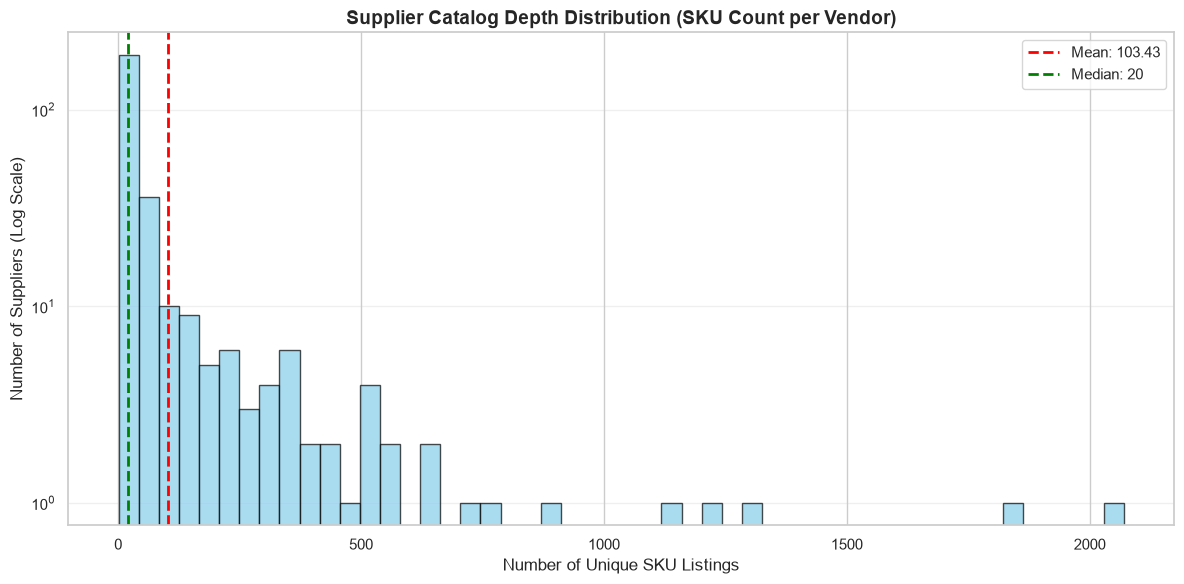


 Top 10 Suppliers by Total Supply Volume:
SUPPLIER
E & J GALLO WINERY                      12169.75000
ANHEUSER BUSCH INC                       8485.46750
CONSTELLATION BRANDS                     7633.29625
THE COUNTRY VINTNER, LLC DBA WINEBOW     7353.74500
LEGENDS LTD                              6862.52625
SOUTHERN GLAZERS WINE AND SPIRITS        5737.48125
REPUBLIC NATIONAL DISTRIBUTING CO        5685.43375
DIAGEO NORTH AMERICA INC                 4987.98500
MILLER BREWING COMPANY                   4984.28000
THE WINE GROUP                           4481.19500
Name: TOTAL_SALES_VOLUME, dtype: float64
✓ Saved: 14_top_suppliers.html

 Supplier Portfolio Strategy Segmentation:
Diverse Portfolio Suppliers (> 114.0 unique items): 19 (6.55%)
Focused/Niche Suppliers (<= 114.0 unique items): 271 (93.45%)


In [6]:
# ============================================================================
# 6. SUPPLIER ENGAGEMENT & PORTFOLIO ANALYSIS (Customer Behavior Replacement)
# ============================================================================

print("\n" + "="*80)
print("SUPPLIER BEHAVIOR AND ENGAGEMENT ANALYSIS")
print("="*80)

# 6.1 Supplier Product Line Breadth (Catalog Frequency)
if 'SUPPLIER' in df.columns:
    print("\n Supplier Catalog Frequency Distribution:")
    supplier_frequency = df.groupby('SUPPLIER').size().reset_index(name='SKU_Appearance_Count')
    
    print(f"Total Unique Suppliers: {len(supplier_frequency):,}")
    print(f"Average SKU Listings per Supplier: {supplier_frequency['SKU_Appearance_Count'].mean():.2f}")
    print(f"Median SKU Listings per Supplier: {supplier_frequency['SKU_Appearance_Count'].median():.0f}")
    
    # Distribution Plot matching your template structure
    plt.figure(figsize=(12, 6))
    plt.hist(supplier_frequency['SKU_Appearance_Count'], bins=50, edgecolor='black', 
             alpha=0.7, color='skyblue')
    plt.title('Supplier Catalog Depth Distribution (SKU Count per Vendor)', fontsize=14, fontweight='bold')
    plt.xlabel('Number of Unique SKU Listings', fontsize=12)
    plt.ylabel('Number of Suppliers', fontsize=12)
    
    sf_mean = supplier_frequency['SKU_Appearance_Count'].mean()
    sf_median = supplier_frequency['SKU_Appearance_Count'].median()
    
    plt.axvline(sf_mean, color='red', linestyle='--', linewidth=2, label=f'Mean: {sf_mean:.2f}')
    plt.axvline(sf_median, color='green', linestyle='--', linewidth=2, label=f'Median: {sf_median:.0f}')
    plt.yscale('log') # Flipped to log scale because a few suppliers list thousands of items
    plt.ylabel('Number of Suppliers (Log Scale)', fontsize=12)
    
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('outputs/figures/13_supplier_frequency.png', dpi=300, bbox_inches='tight')
    print("✓ Saved: 13_supplier_frequency.png")
    plt.show()

# 6.2 Top Suppliers by Total Distributed Volume
if 'SUPPLIER' in df.columns and 'TOTAL_SALES_VOLUME' in df.columns:
    print("\n Top 10 Suppliers by Total Supply Volume:")
    top_suppliers = df.groupby('SUPPLIER')['TOTAL_SALES_VOLUME'].sum().sort_values(ascending=False).head(10)
    print(top_suppliers)
    
    # Interactive Bar Chart matching template formatting
    fig = px.bar(top_suppliers.reset_index(), 
                 x='SUPPLIER', 
                 y='TOTAL_SALES_VOLUME',
                 title='Top 10 High-Velocity Suppliers by Transacted Volume',
                 labels={'TOTAL_SALES_VOLUME': 'Total Volume (Units)', 'SUPPLIER': 'Supplier Name'},
                 color='TOTAL_SALES_VOLUME',
                 color_continuous_scale='reds')
    fig.update_layout(xaxis_tickangle=-45)
    fig.write_html('outputs/figures/14_top_suppliers.html')
    print("✓ Saved: 14_top_suppliers.html")

# 6.3 Supplier Portfolio Segments (Diverse vs Focus Partners)
if 'SUPPLIER_UNIQUE_ITEMS' in df.columns:
    print("\n Supplier Portfolio Strategy Segmentation:")
    
    # Classify based on whether they bring a wide catalog variation or narrow focus
    # Using the median of unique item count across the dataset as the threshold splitting line
    median_sku_threshold = df['SUPPLIER_UNIQUE_ITEMS'].median()
    
    supplier_profiles = df.groupby('SUPPLIER')['SUPPLIER_UNIQUE_ITEMS'].max()
    diverse_partners = (supplier_profiles > median_sku_threshold).sum()
    total_partners = len(supplier_profiles)
    diverse_pct = (diverse_partners / total_partners) * 100
    
    print(f"Diverse Portfolio Suppliers (> {median_sku_threshold} unique items): {diverse_partners:,} ({diverse_pct:.2f}%)")
    print(f"Focused/Niche Suppliers (<= {median_sku_threshold} unique items): {total_partners - diverse_partners:,} ({100 - diverse_pct:.2f}%)")

In [7]:
# ============================================================================
# 7. PRODUCT PERFORMANCE ANALYSIS
# ============================================================================

print("\n" + "="*80)
print("PRODUCT PERFORMANCE ANALYSIS")
print("="*80)

# 7.1 Top Selling Products (Dual Axis: Retail Volume vs Warehouse Volume)
if 'ITEM DESCRIPTION' in df.columns and 'TOTAL_SALES_VOLUME' in df.columns:
    print("\n Top 20 Product Items by Transacted Volume:")
    
    # Aggregate specific supply channels for top products
    product_performance = df.groupby('ITEM DESCRIPTION').agg({
        'TOTAL_SALES_VOLUME': 'sum',
        'RETAIL SALES': 'sum',
        'WAREHOUSE SALES': 'sum'
    }).sort_values('TOTAL_SALES_VOLUME', ascending=False).head(20)
    
    print(product_performance)
    
    # Dual axis chart matching template structure
    fig = go.Figure()
    
    # Primary Axis - Retail sales bars
    fig.add_trace(go.Bar(
        x=product_performance.index,
        y=product_performance['RETAIL SALES'],
        name='Retail Storefront Volume',
        marker_color='indianred',
        yaxis='y'
    ))
    
    # Secondary Axis - Warehouse sales line
    fig.add_trace(go.Scatter(
        x=product_performance.index,
        y=product_performance['WAREHOUSE SALES'],
        name='B2B Warehouse Volume',
        mode='lines+markers',
        marker_color='lightsalmon',
        yaxis='y2'
    ))
    
    fig.update_layout(
        title='Top 20 Products: Retail Storefront vs B2B Warehouse Volume Breakdown',
        xaxis=dict(title='Product Name / Description', tickangle=45),
        yaxis=dict(title='Retail Units Sold', side='left'),
        yaxis2=dict(title='Warehouse Units Sold', overlaying='y', side='right'),
        hovermode='x unified',
        height=650,
        legend=dict(x=0.01, y=0.99, xanchor='left', yanchor='top')
    )
    fig.write_html('outputs/figures/15_top_products.html')
    print("✓ Saved: 15_top_products.html")

# 7.2 Category Performance Matrix
if 'ITEM TYPE' in df.columns:
    print("\n Category Performance Matrix:")
    
    # Rebuild matrix using your real supply chain features
    category_matrix = df.groupby('ITEM TYPE').agg({
        'TOTAL_SALES_VOLUME': ['sum', 'mean'],
        'ITEM CODE': 'count',
        'SUPPLIER': 'nunique'
    })
    category_matrix.columns = ['Total_Volume', 'Avg_Volume_Per_SKU', 'Record_Count', 'Unique_Suppliers']
    category_matrix['Volume_Share_Pct'] = (category_matrix['Total_Volume'] / category_matrix['Total_Volume'].sum() * 100).round(2)
    print(category_matrix.round(2))
    
    # Scatter matrix plot (Bubble chart) matching template parameters
    fig = px.scatter(category_matrix.reset_index(), 
                     x='Record_Count', 
                     y='Avg_Volume_Per_SKU',
                     size='Total_Volume', 
                     color='ITEM TYPE',
                     title='Category Performance Matrix: Record Appearances vs Avg SKU Volume (Size = Total Volume)',
                     labels={'Record_Count': 'Number of Row Appearances (Frequency)', 
                             'Avg_Volume_Per_SKU': 'Average Velocity Units Per SKU'},
                     hover_data=['Total_Volume', 'Unique_Suppliers'])
    
    fig.write_html('outputs/figures/16_category_performance.html')
    print("✓ Saved: 16_category_performance.html")

# 7.3 Pareto Analysis (80-20 Rule)
if 'ITEM CODE' in df.columns and 'TOTAL_SALES_VOLUME' in df.columns:
    print("\n Pareto Analysis (80-20 Rule) on Inventory Volume:")
    
    # Compute cumulative volume percentages
    product_volumes = df.groupby('ITEM CODE')['TOTAL_SALES_VOLUME'].sum().sort_values(ascending=False)
    product_volumes_cumsum = product_volumes.cumsum() / product_volumes.sum() * 100
    
    # Locate the tipping point threshold under 80%
    top_80_pct = (product_volumes_cumsum <= 80).sum()
    pct_products = (top_80_pct / len(product_volumes)) * 100
    
    print(f"  • Top {top_80_pct} distinct SKUs ({pct_products:.2f}%) generate 80% of total distribution volume.")
    print(f"  • Total active unique products in catalog: {len(product_volumes):,}")


PRODUCT PERFORMANCE ANALYSIS

 Top 20 Product Items by Transacted Volume:
                                         TOTAL_SALES_VOLUME  RETAIL SALES  \
ITEM DESCRIPTION                                                            
MONTEZUMA TEQUILA - GOLD - 1L                      89.22500      29.22500   
BOGLE CHARD - 750ML                                89.22500      29.22500   
KRIS P/GRIG - 750ML                                89.22500      29.22500   
CUSQUENA BEER-PERU 4/6 NR - 12OZ                   89.22500      29.22500   
CAPRICCIO WATERMELON SANGRIA - 750ML               89.22500      29.22500   
TROEGS TROEGENATOR 4/6 NR                          89.22500      29.22500   
KONA LONGBOARD 4/6 NR - 12OZ                       89.22500      29.22500   
CASAL GARCIA VINHO VERDE BRANCO - 750ML            89.22500      29.22500   
CANYON ROAD CAB - 750ML                            89.22500      29.22500   
CAPRICCIO ROSE SANGRIA - 750ML                     89.22500      29.22500   
H

In [8]:
# ============================================================================
# 8. ADVANCED INSIGHTS
# ============================================================================

print("\n" + "="*80)
print("ADVANCED INSIGHTS")
print("="*80)

# 8.1 Distribution Volume Percentile Analysis
if 'TOTAL_SALES_VOLUME' in df.columns:
    print("\n Aggregate Distribution Volume Profile:")
    print(f"  • Mean Unit Flow:     {df['TOTAL_SALES_VOLUME'].mean():.2f}")
    print(f"  • Median Unit Flow:   {df['TOTAL_SALES_VOLUME'].median():.2f}")
    print(f"  • Std Deviation:      {df['TOTAL_SALES_VOLUME'].std():.2f}")
    print(f"  • Min Single Record:  {df['TOTAL_SALES_VOLUME'].min():.2f}")
    print(f"  • Max Single Record:  {df['TOTAL_SALES_VOLUME'].max():.2f}")
    
    print("\n Volume Velocity Percentiles (SKU Scaling):")
    for p in [25, 50, 75, 90, 95, 99]:
        print(f"   - {p}th Percentile: {df['TOTAL_SALES_VOLUME'].quantile(p/100):,.2f} units")

# 8.2 Fulfillment Channel Balance Matrix (Replacing Discount Impact)
if 'RETAIL_CHANNEL_PCT' in df.columns and 'TOTAL_SALES_VOLUME' in df.columns:
    print("\n Fulfillment Channel Concentration Analysis:")
    
    # Segment records based on which supply lane dominates the row's volume
    channel_conditions = [
        (df['TOTAL_SALES_VOLUME'] == 0),
        (df['RETAIL_CHANNEL_PCT'] == 100),
        (df['WAREHOUSE_CHANNEL_PCT'] == 100),
        (df['RETAIL_CHANNEL_PCT'] >= 50),
        (df['WAREHOUSE_CHANNEL_PCT'] > 50)
    ]
    channel_labels = ['No Volume Moving', 'Pure Storefront Retail', 'Pure B2B Warehouse', 'Hybrid (Retail Leaning)', 'Hybrid (Warehouse Leaning)']
    
    df['CHANNEL_STRATEGY_SEGMENT'] = np.select(channel_conditions, channel_labels, default='Balanced Hybrid')
    
    channel_insights = df.groupby('CHANNEL_STRATEGY_SEGMENT')['TOTAL_SALES_VOLUME'].agg(['count', 'mean', 'sum']).round(2)
    channel_insights.columns = ['Record_Count', 'Avg_Volume_Per_Record', 'Total_Channel_Volume']
    print(channel_insights.sort_values(by='Total_Channel_Volume', ascending=False))

# 8.3 Logistical Transfer Friction Analysis (Replacing Delivery Performance)
if 'TRANSFER_TO_SALES_RATIO' in df.columns:
    print("\n Supply Chain Logistical Friction Metrics:")
    print(f"  • Average Stock Transfer Ratio: {df['TRANSFER_TO_SALES_RATIO'].mean():.3f}")
    print(f"  • Median Stock Transfer Ratio:  {df['TRANSFER_TO_SALES_RATIO'].median():.3f}")
    
    # Categorize friction levels: High ratio means inventory is shifting more than selling
    friction_groups = pd.cut(df['TRANSFER_TO_SALES_RATIO'], 
                             bins=[-0.01, 0.00, 0.20, 1.00, np.inf], 
                             labels=['Zero Friction (No Transfers)', 'Stable Logistics (0-20%)', 'High Rotation (20-100%)', 'Supply Chain Strain (>100%)'])
    
    friction_dist = friction_groups.value_counts()
    print("\n Logistical Tension Category Distribution:")
    print(friction_dist)


ADVANCED INSIGHTS

 Aggregate Distribution Volume Profile:
  • Mean Unit Flow:     5.90
  • Median Unit Flow:   3.00
  • Std Deviation:      6.67
  • Min Single Record:  0.00
  • Max Single Record:  22.31

 Volume Velocity Percentiles (SKU Scaling):
   - 25th Percentile: 1.00 units
   - 50th Percentile: 3.00 units
   - 75th Percentile: 8.22 units
   - 90th Percentile: 17.31 units
   - 95th Percentile: 22.31 units
   - 99th Percentile: 22.31 units

 Fulfillment Channel Concentration Analysis:
                            Record_Count  Avg_Volume_Per_Record  \
CHANNEL_STRATEGY_SEGMENT                                          
Hybrid (Warehouse Leaning)          6566                  14.00   
Pure B2B Warehouse                 13403                   3.73   
Pure Storefront Retail              7712                   2.37   
Hybrid (Retail Leaning)             2027                   8.35   
No Volume Moving                     288                   0.00   

                            Tota

In [9]:
# ============================================================================
# 9. KEY FINDINGS SUMMARY
# ============================================================================

print("\n" + "="*80)
print("KEY FINDINGS FROM EDA")
print("="*80)

findings = []

# Finding 1: Dominant Item Category Contribution
if 'ITEM TYPE' in df.columns and 'TOTAL_SALES_VOLUME' in df.columns:
    cat_volumes = df.groupby('ITEM TYPE')['TOTAL_SALES_VOLUME'].sum()
    top_category = cat_volumes.idxmax()
    top_category_pct = (cat_volumes.max() / cat_volumes.sum() * 100)
    findings.append(f"1. Category Alpha: '{top_category}' is the dominant item category, generating {top_category_pct:.2f}% of total distributed volume.")

# Finding 2: Supplier Catalog Diversity Spread
if 'SUPPLIER_UNIQUE_ITEMS' in df.columns:
    supplier_profiles = df.groupby('SUPPLIER')['SUPPLIER_UNIQUE_ITEMS'].max()
    median_sku_threshold = df['SUPPLIER_UNIQUE_ITEMS'].median()
    diverse_partners = (supplier_profiles > median_sku_threshold).sum()
    total_partners = len(supplier_profiles)
    diverse_pct = (diverse_partners / total_partners * 100)
    findings.append(f"2. Vendor Ecosystem: Diverse portfolio suppliers make up {diverse_pct:.2f}% ({diverse_partners:,} of {total_partners:,} vendors), anchoring wide product availability.")

# Finding 3: Operational Peak Seasonality
if 'SEASON' in df.columns and 'TOTAL_SALES_VOLUME' in df.columns:
    seasonal_volumes = df.groupby('SEASON')['TOTAL_SALES_VOLUME'].sum()
    peak_season = seasonal_volumes.idxmax()
    peak_pct = (seasonal_volumes.max() / seasonal_volumes.sum() * 100)
    findings.append(f"3. Macro Timeline: The '{peak_season}' seasonal window represents peak operations, absorbing {peak_pct:.2f}% of aggregate distribution units.")

# Finding 4: Fulfillment Channel Bias Mix
if 'RETAIL SALES' in df.columns and 'WAREHOUSE SALES' in df.columns:
    total_retail = df['RETAIL SALES'].sum()
    total_warehouse = df['WAREHOUSE SALES'].sum()
    grand_total = total_retail + total_warehouse
    
    retail_share = (total_retail / grand_total * 100)
    warehouse_share = (total_warehouse / grand_total * 100)
    dominant_channel = "Storefront Retail" if total_retail > total_warehouse else "B2B Warehouse Fulfillment"
    
    findings.append(f"4. Fulfillment Mix: Supply operations lean toward {dominant_channel} (Retail: {retail_share:.1f}% vs. Warehouse: {warehouse_share:.1f}%).")

# Finding 5: Operational Pareto Concentration (80-20 Rule Alignment)
if 'ITEM CODE' in df.columns and 'TOTAL_SALES_VOLUME' in df.columns:
    product_volumes = df.groupby('ITEM CODE')['TOTAL_SALES_VOLUME'].sum().sort_values(ascending=False)
    top_20_count = max(1, int(len(product_volumes) * 0.2))
    top_20_volume_pct = (product_volumes.head(top_20_count).sum() / product_volumes.sum() * 100)
    findings.append(f"5. Portfolio Velocity: The top 20% of active SKUs generate {top_20_volume_pct:.2f}% of total operational throughput, explicitly confirming the Pareto Principle.")

# Output findings to console
for finding in findings:
    print(f"\n{finding}")

# Save findings text report to disk
findings_text = "\n".join(findings)
with open('outputs/reports/03_eda_key_findings.txt', 'w') as f:
    f.write("KEY FINDINGS FROM EXPLORATORY DATA ANALYSIS\n")
    f.write("="*80 + "\n\n")
    f.write(findings_text)
    f.write(f"\n\nReport Compiled: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}")

print("\n✓ Key findings saved to: outputs/reports/03_eda_key_findings.txt")

print("\n" + "="*80)
print("Part 3 (EDA) COMPLETED SUCCESSFULLY!")
print("="*80)
print("\n Next Step: Part 4 - Customer Segmentation & Advanced Analytics")
print("="*80)


KEY FINDINGS FROM EDA

1. Category Alpha: 'WINE' is the dominant item category, generating 55.21% of total distributed volume.

2. Vendor Ecosystem: Diverse portfolio suppliers make up 6.55% (19 of 290 vendors), anchoring wide product availability.

3. Macro Timeline: The 'Winter' seasonal window represents peak operations, absorbing 40.91% of aggregate distribution units.

4. Fulfillment Mix: Supply operations lean toward B2B Warehouse Fulfillment (Retail: 31.7% vs. Warehouse: 68.3%).

5. Portfolio Velocity: The top 20% of active SKUs generate 66.37% of total operational throughput, explicitly confirming the Pareto Principle.

✓ Key findings saved to: outputs/reports/03_eda_key_findings.txt

Part 3 (EDA) COMPLETED SUCCESSFULLY!

 Next Step: Part 4 - Customer Segmentation & Advanced Analytics
